In [2]:
import pandas as pd

data = {
    'weight_kg':
        [65.835312, 80.423971, 75.862873, 63.812162, 58.489834, 60.796297, 62.537917, 77.179851, 68.597246, 72.819004],
    'height_cm':
        [164.981605, 188.028572, 179.279758, 173.946339, 156.240746, 156.239781, 152.323344, 184.647046, 174.044600,
         178.322903],
}

df = pd.DataFrame(data)
df[:5]

,weight_kg,height_cm
0,65.835312,164.981605
1,80.423971,188.028572
2,75.862873,179.279758
3,63.812162,173.946339
4,58.489834,156.240746


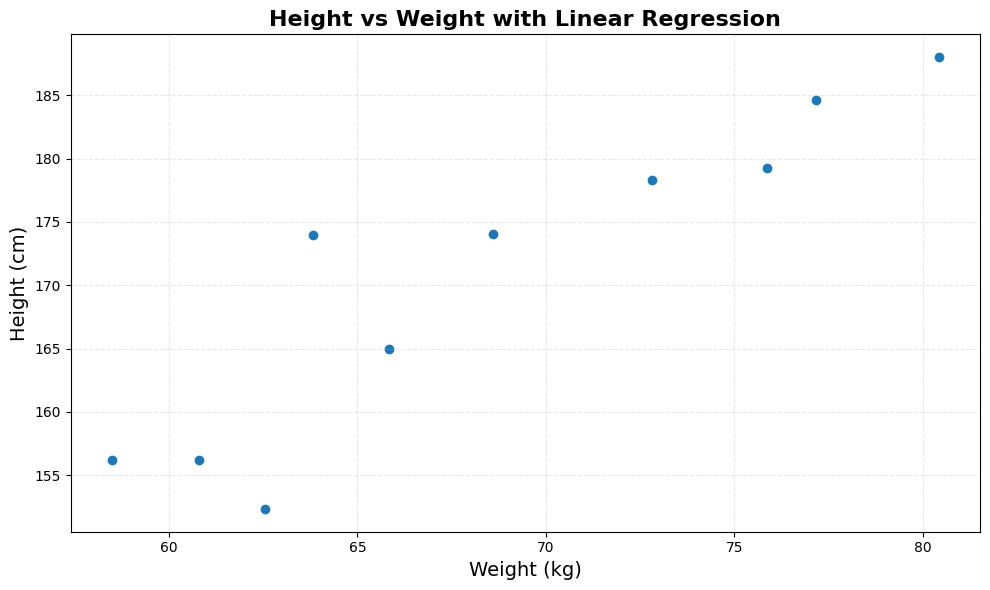

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['weight_kg'], df['height_cm'])
plt.title('Height vs Weight with Linear Regression', fontsize=16, fontweight='bold')
plt.xlabel('Weight (kg)', fontsize=14)
plt.ylabel('Height (cm)', fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)

In [4]:
X = df[['weight_kg']]
y = df['height_cm']

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.54]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['weight_kg']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,65.44
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [6]:
import numpy as np

# 3. Generate a smooth line for plotting
X_line = pd.DataFrame(
    np.linspace(X['weight_kg'].min(), X['weight_kg'].max(), 100),
    columns=['weight_kg']
)

y_line = model.predict(X_line)

In [7]:
X_line[:3], y_line[:3]

(   weight_kg
 0  58.489834
 1  58.711391
 2  58.932948,
 array([155.23001891, 155.57015107, 155.91028322]))

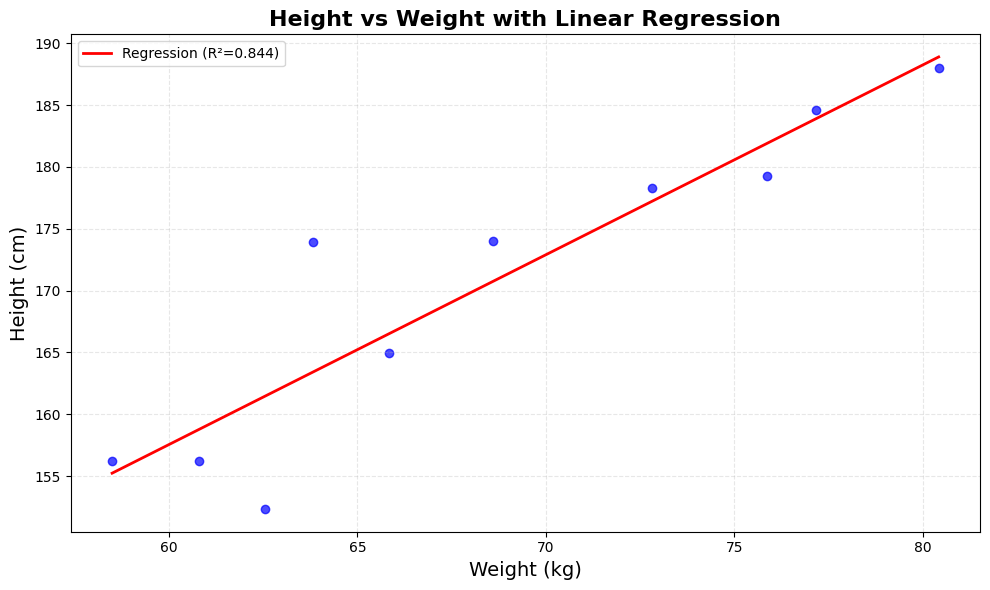

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['weight_kg'], df['height_cm'], color='blue', alpha=0.7)
plt.plot(X_line, y_line, color='red', linewidth=2,
         label=f'Regression (R²={model.score(X, y):.3f})')

plt.title('Height vs Weight with Linear Regression', fontsize=16, fontweight='bold')
plt.xlabel('Weight (kg)', fontsize=14)
plt.ylabel('Height (cm)', fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

In [9]:
y_pred = model.predict(X)

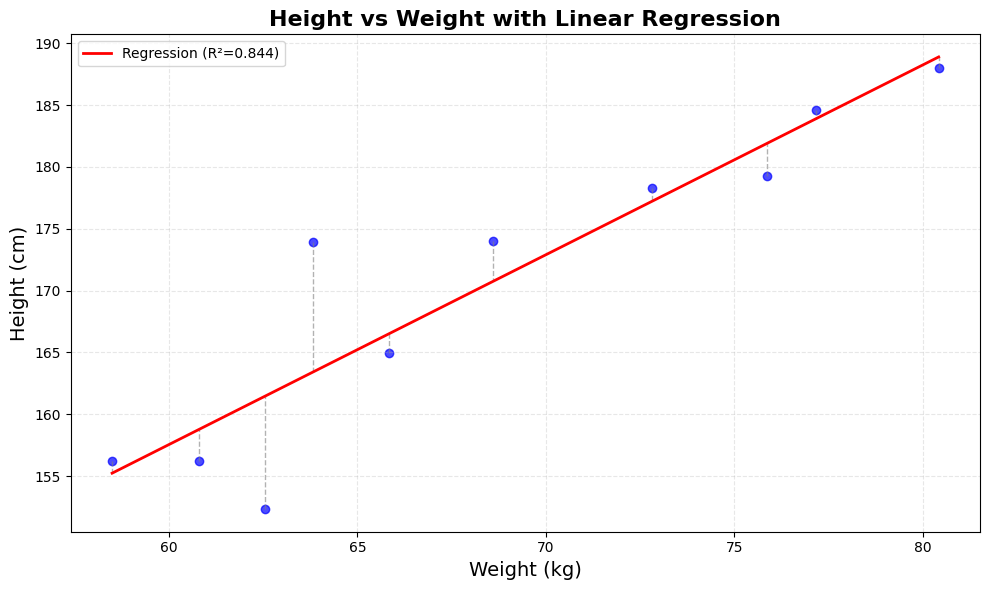

In [10]:
plt.figure(figsize=(10, 6))

# 1. Scatter plot of actual data
plt.scatter(df['weight_kg'], df['height_cm'], color='blue', alpha=0.7)

# 2. Regression line
plt.plot(X_line, y_line, color='red', linewidth=2,
         label=f'Regression (R²={model.score(X, y):.3f})')

# 3. Vertical lines (residuals) from each point to the regression line
for i in range(len(X)):
    plt.plot(
        [X.iloc[i, 0], X.iloc[i, 0]],  # x start and end (same x)
        [y.iloc[i], y_pred[i]],         # y start (actual) to y end (predicted)
        color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=1
    )

plt.title('Height vs Weight with Linear Regression', fontsize=16, fontweight='bold')
plt.xlabel('Weight (kg)', fontsize=14)
plt.ylabel('Height (cm)', fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()